<a href="https://colab.research.google.com/github/nikitamkoli21-ship-it/QMLHEP-GSoC-2026/blob/main/Task_VIII_Vision_Transformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install torch torchvision matplotlib

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 540kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.55MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.77MB/s]


Train size: 60000
Test size: 10000


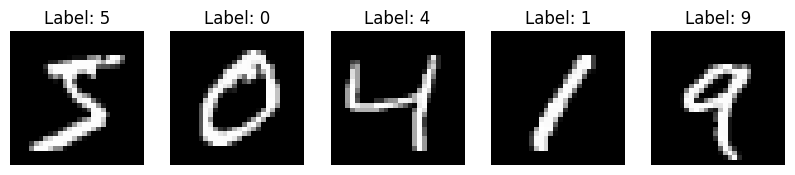

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(root='./data', train=True,
                                download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False,
                               download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))

fig, axes = plt.subplots(1, 5, figsize=(10, 2))
for i, ax in enumerate(axes):
    ax.imshow(train_dataset[i][0].squeeze(), cmap='gray')
    ax.set_title(f"Label: {train_dataset[i][1]}")
    ax.axis('off')
plt.show()

In [3]:
class PatchEmbedding(nn.Module):
    """Split image into patches and embed them"""
    def __init__(self, img_size=28, patch_size=7,
                 in_channels=1, embed_dim=64):
        super().__init__()
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2
        self.projection = nn.Linear(
            patch_size * patch_size * in_channels, embed_dim
        )

    def forward(self, x):
        B, C, H, W = x.shape
        p = self.patch_size
        x = x.unfold(2, p, p).unfold(3, p, p)
        x = x.contiguous().view(B, -1, p * p * C)
        x = self.projection(x)
        return x


class TransformerBlock(nn.Module):
    """One transformer layer with attention + feedforward"""
    def __init__(self, embed_dim=64, num_heads=4, mlp_dim=128):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = nn.MultiheadAttention(embed_dim, num_heads,
                                           batch_first=True)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, mlp_dim),
            nn.GELU(),
            nn.Linear(mlp_dim, embed_dim)
        )

    def forward(self, x):
        x = x + self.attn(self.norm1(x),
                           self.norm1(x),
                           self.norm1(x))[0]
        x = x + self.mlp(self.norm2(x))
        return x


class VisionTransformer(nn.Module):
    """Full Vision Transformer for MNIST"""
    def __init__(self, img_size=28, patch_size=7, in_channels=1,
                 embed_dim=64, num_heads=4, num_layers=4,
                 mlp_dim=128, num_classes=10):
        super().__init__()

        self.patch_embed = PatchEmbedding(
            img_size, patch_size, in_channels, embed_dim
        )
        num_patches = (img_size // patch_size) ** 2
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(
            torch.zeros(1, num_patches + 1, embed_dim)
        )
        self.transformer = nn.Sequential(*[
            TransformerBlock(embed_dim, num_heads, mlp_dim)
            for _ in range(num_layers)
        ])

        self.norm = nn.LayerNorm(embed_dim)
        self.classifier = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        B = x.shape[0]
        x = self.patch_embed(x)
        cls = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls, x], dim=1)
        x = x + self.pos_embed

        x = self.transformer(x)
        x = self.norm(x)
        x = self.classifier(x[:, 0])
        return x

model = VisionTransformer()
print("ViT model ready!")
print("Total parameters:",
      sum(p.numel() for p in model.parameters()))

ViT model ready!
Total parameters: 139018


In [4]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

def train(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for images, labels in loader:
        optimizer.zero_grad()
        out = model(images)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            out = model(images)
            pred = out.argmax(dim=1)
            correct += (pred == labels).sum().item()
            total += labels.size(0)
    return correct / total * 100
for epoch in range(5):
    loss = train(model, train_loader, optimizer, criterion)
    acc = evaluate(model, test_loader)
    print(f"Epoch {epoch+1}/5 | Loss: {loss:.3f} | Test Acc: {acc:.2f}%")

Epoch 1/5 | Loss: 0.469 | Test Acc: 95.26%
Epoch 2/5 | Loss: 0.152 | Test Acc: 96.26%
Epoch 3/5 | Loss: 0.110 | Test Acc: 97.05%
Epoch 4/5 | Loss: 0.087 | Test Acc: 97.67%
Epoch 5/5 | Loss: 0.074 | Test Acc: 97.11%


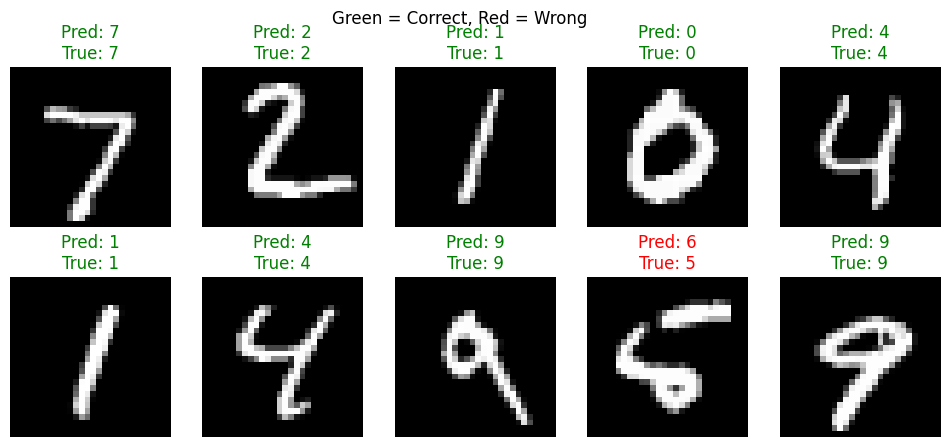

In [7]:
model.eval()
images, labels = next(iter(test_loader))
with torch.no_grad():
    preds = model(images).argmax(dim=1)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i].squeeze(), cmap='gray')
    color = 'green' if preds[i] == labels[i] else 'red'
    ax.set_title(f"Pred: {preds[i].item()}\nTrue: {labels[i].item()}",
                 color=color)
    ax.axis('off')
plt.suptitle("Green = Correct, Red = Wrong")
plt.show()

## How ViT Works
- Image split into 16 patches (4x4 grid of 7x7 patches)
- Each patch embedded into 64-dimensional vector
- CLS token added for classification
- Position embeddings added so model knows patch order
- 4 Transformer layers process patches using attention
- Final classification done using CLS token

## Ideas to Extend to Quantum Vision Transformer
1. Quantum Patch Embedding — use PQC instead of linear layer
2. Quantum Attention — use SWAP test to measure patch similarity
3. Quantum MLP — replace feedforward layers with quantum circuits